# **Uber Supply Demand Gap - EDA Project**

##### **Project Type**    - EDA (Exploratory Data Analysis)
##### **Contribution**    - Individual
##### **Team Member 1 -** Pallavi Pagar

# **Project Summary -**

Uber is one of the largest ride-hailing platforms in the world, connecting riders with drivers through its mobile app. A recurring operational challenge for Uber is the **supply-demand gap** — situations where a rider requests a cab but the trip does not get completed, either because **"No Cars Available"** or because the **driver/rider cancels** the request. This gap directly affects revenue, customer satisfaction and driver utilization.

This project analyzes a real-world Uber request dataset containing **6,745 ride requests** made between two pickup points — **City** and **Airport** — over a period of five days in July 2016. Each record captures the Request ID, Pickup point, Driver ID, trip Status (Trip Completed / Cancelled / No Cars Available), Request timestamp and Drop timestamp.

The analysis begins with data cleaning and wrangling: parsing timestamps, handling missing values (Driver ID is missing for unfulfilled requests, and Drop timestamp is missing for anything other than a completed trip), and engineering new features such as **Request Hour**, **Request Day**, **Day of Week**, and a categorical **Time Slot** (Late Night, Early Morning, Morning, Afternoon, Evening, Night) that groups the 24-hour clock into meaningful operational windows.

Using this enriched dataset, the notebook explores the distribution of trip statuses, the split of demand between City and Airport, and — most importantly — **when and where the supply-demand gap is concentrated**. Fifteen visualizations are used to build the story, including hourly demand charts, time-slot based gap charts, pickup-point based gap charts, a status-vs-time-slot heatmap, and a correlation heatmap of the engineered numeric features.

The key finding is that the supply-demand gap is **not uniform across the day** and behaves very differently at the two pickup points:
- At the **Airport**, the dominant problem is **"No Cars Available"**, heavily concentrated in the **Evening and Night** slots, when riders land and need a cab back to the city but very few drivers are willing to be at the airport during these hours.
- In the **City**, the dominant problem is **cancellations**, heavily concentrated in the **Early Morning** and **Morning** slots, when drivers accept a City-to-Airport trip but then cancel it — most likely because they prefer not to make a long trip to the airport and then wait/return empty, or because they'd rather stay in the city to catch shorter, more frequent city trips.

Together, these two patterns explain the overall shape of the gap: total unfulfilled requests peak sharply during Evening/Night (Airport, no cars) and again during Early Morning (City, cancellations), while Afternoon has the smallest gap of the day.

Based on these insights, the notebook proposes two data-backed business solutions: **surge/rush-hour incentive pricing** for drivers who pick up passengers from the City during Early Morning hours, and a **dedicated evening/night-shift driver pool** stationed at the Airport to reduce "No Cars Available" instances. Implementing either lever should measurably reduce the unfulfilled request count and directly improve Uber's realized revenue and customer experience at both pickup points.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**

Uber faces a **supply-demand gap** — many ride requests end in either **"Cancelled"** or **"No Cars Available"** instead of a completed trip. This is especially visible on trips to and from the **Airport**. The goal of this analysis is to explore Uber's request data to identify the **time slots and pickup points** that suffer the most from this gap, understand **why** trips are not being completed (cancellations vs unavailability), and recommend **data-driven solutions** to reduce the gap and improve the number of successfully completed trips.

#### **Define Your Business Objective?**

To identify the root causes of the supply-demand gap (unfulfilled requests) across different pickup points (City/Airport) and time slots, and to recommend actionable strategies that Uber can implement to reduce the number of "Cancelled" and "No Cars Available" requests, thereby increasing completed trips and revenue.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)


### Dataset Loading

In [2]:
# Load Dataset
df = pd.read_csv('Uber_Request_Data.csv')


### Dataset First View

In [3]:
# Dataset First Look
df.head()


<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>Request id</th>
      <th>Pickup point</th>
      <th>Driver id</th>
      <th>Status</th>
      <th>Request timestamp</th>
      <th>Drop timestamp</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>619</td>
      <td>Airport</td>
      <td>1.0</td>
      <td>Trip Completed</td>
      <td>11/07/16 11:51</td>
      <td>11/07/16 13:00</td>
    </tr>
    <tr>
      <th>1</th>
      <td>867</td>
      <td>Airport</td>
      <td>1.0</td>
      <td>Trip Completed</td>
      <td>11/07/16 17:57</td>
      <td>11/07/16 18:47</td>
    </tr>
    <tr>
      <th>2</th>
      <td>1807</td>
      <td>City</td>
      <td>1.0</td>
      <td>Tr

### Dataset Rows & Columns count

In [4]:
# Dataset Rows & Columns count
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")


Number of rows: 6745
Number of columns: 6


### Dataset Information

In [5]:
# Dataset Info
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 6745 entries, 0 to 6744
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Request id         6745 non-null   int64  
 1   Pickup point       6745 non-null   str    
 2   Driver id          4095 non-null   float64
 3   Status             6745 non-null   str    
 4   Request timestamp  6745 non-null   str    
 5   Drop timestamp     2831 non-null   str    
dtypes: float64(1), int64(1), str(4)
memory usage: 316.3 KB
<class 'pandas.DataFrame'>
RangeIndex: 6745 entries, 0 to 6744
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Request id         6745 non-null   int64  
 1   Pickup point       6745 non-null   str    
 2   Driver id          4095 non-null   float64
 3   Status             6745 non-null   str    
 4   Request timestamp  6745 non-null   str    
 5   Drop timestamp     2831 n

#### Duplicate Values

In [6]:
# Dataset Duplicate Value Count
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")


Number of duplicate rows: 0


#### Missing Values/Null Values

In [7]:
# Missing Values/Null Values Count
df.isnull().sum()


Request id              0
Pickup point            0
Driver id            2650
Status                  0
Request timestamp       0
Drop timestamp       3914
dtype: int64

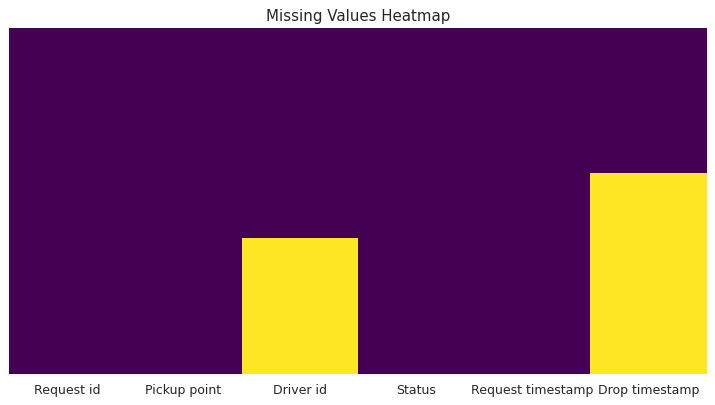

In [8]:
# Visualizing the missing values
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap')
plt.show()


### What did you know about your dataset?

The dataset contains **6,745 ride requests** with **6 columns**: `Request id`, `Pickup point`, `Driver id`, `Status`, `Request timestamp`, and `Drop timestamp`. There are **no duplicate rows**.

Two columns have missing values, and both are missing *by design* rather than by data-quality error:
- **`Driver id`** is missing for **2,650** requests — these correspond exactly to requests with Status = "No Cars Available" (no driver was ever assigned).
- **`Drop timestamp`** is missing for **3,914** requests — these correspond to every request that is **not** "Trip Completed" (i.e., Cancelled or No Cars Available), since a trip that never happened has no drop time.

The `Status` column has 3 categories: **Trip Completed (2,831)**, **No Cars Available (2,650)**, and **Cancelled (1,264)** — meaning roughly **58%** of all requests did **not** end in a completed trip, confirming a large supply-demand gap. `Pickup point` has 2 categories: **City (3,507)** and **Airport (3,238)**.

## ***2. Understanding Your Variables***

In [9]:
# Dataset Columns
df.columns


Index(['Request id', 'Pickup point', 'Driver id', 'Status',
       'Request timestamp', 'Drop timestamp'],
      dtype='str')

In [10]:
# Dataset Describe
df.describe(include='all')


<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>Request id</th>
      <th>Pickup point</th>
      <th>Driver id</th>
      <th>Status</th>
      <th>Request timestamp</th>
      <th>Drop timestamp</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>count</th>
      <td>6745.000000</td>
      <td>6745</td>
      <td>4095.000000</td>
      <td>6745</td>
      <td>6745</td>
      <td>2831</td>
    </tr>
    <tr>
      <th>unique</th>
      <td>NaN</td>
      <td>2</td>
      <td>NaN</td>
      <td>3</td>
      <td>4016</td>
      <td>2282</td>
    </tr>
    <tr>
      <th>top</th>
      <td>NaN</td>
      <td>City</td>
      <td>NaN</td>
      <td>Trip Completed</td>
      <td>15/07/16 19:19</td

### Variables Description

- **Request id** — Unique identifier for each ride request.
- **Pickup point** — Where the ride was requested from: `City` or `Airport`.
- **Driver id** — Unique identifier of the driver assigned to the request (blank if no driver could be assigned).
- **Status** — Final outcome of the request: `Trip Completed`, `Cancelled`, or `No Cars Available`.
- **Request timestamp** — Date & time the rider made the request.
- **Drop timestamp** — Date & time the trip ended (only populated for completed trips).

### Check Unique Values for each variable.

In [11]:
# Check Unique Values for each variable.
for column in df.columns:
    print(f"{column}: {df[column].nunique()} unique values")


Request id: 6745 unique values
Pickup point: 2 unique values
Driver id: 300 unique values
Status: 3 unique values
Request timestamp: 4016 unique values
Drop timestamp: 2282 unique values


## 3. ***Data Wrangling***

### Data Wrangling Code

In [12]:
# Write your code to make your dataset analysis ready.

# Parse timestamps (mixed day-first formats present in the raw file)
df['Request timestamp'] = pd.to_datetime(df['Request timestamp'], format='mixed', dayfirst=True)
df['Drop timestamp'] = pd.to_datetime(df['Drop timestamp'], format='mixed', dayfirst=True)

# Extract useful date/time parts from the request timestamp
df['Request Day'] = df['Request timestamp'].dt.day
df['Request Hour'] = df['Request timestamp'].dt.hour
df['Request Day of Week'] = df['Request timestamp'].dt.day_name()

# Bucket the hour of day into operational time slots
def get_time_slot(hour):
    if 0 <= hour < 5:
        return 'Late Night'
    elif 5 <= hour < 10:
        return 'Early Morning'
    elif 10 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 20:
        return 'Evening'
    else:
        return 'Night'

df['Time Slot'] = df['Request Hour'].apply(get_time_slot)

# Flag: was the request a supply-demand GAP (not completed)?
df['Is Gap'] = df['Status'].apply(lambda s: 1 if s != 'Trip Completed' else 0)

# Trip duration in minutes, where available
df['Trip Duration (mins)'] = (df['Drop timestamp'] - df['Request timestamp']).dt.total_seconds() / 60

df.head()


<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>Request id</th>
      <th>Pickup point</th>
      <th>Driver id</th>
      <th>Status</th>
      <th>Request timestamp</th>
      <th>Drop timestamp</th>
      <th>Request Day</th>
      <th>Request Hour</th>
      <th>Request Day of Week</th>
      <th>Time Slot</th>
      <th>Is Gap</th>
      <th>Trip Duration (mins)</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>619</td>
      <td>Airport</td>
      <td>1.0</td>
      <td>Trip Completed</td>
      <td>2016-07-11 11:51:00</td>
      <td>2016-07-11 13:00:00</td>
      <td>11</td>
      <td>11</td>
      <td>Monday</td>
      <td>Morning</td>
      <td>0</td>
      <td>69.

### What all manipulations have you done and insights you found?

**Manipulations performed:**
1. Converted `Request timestamp` and `Drop timestamp` from text to proper `datetime` objects.
2. Engineered `Request Day`, `Request Hour`, and `Request Day of Week` from the request timestamp.
3. Created a categorical `Time Slot` feature (Late Night, Early Morning, Morning, Afternoon, Evening, Night) by bucketing the hour of day into operationally meaningful windows.
4. Created a binary `Is Gap` flag (1 = request NOT completed, 0 = Trip Completed) to make it easy to isolate the supply-demand gap.
5. Computed `Trip Duration (mins)` for completed trips using the difference between drop and request timestamps.

**Insights found:** After wrangling, it becomes clear that the data spans **5 consecutive days** (11–15 July 2016) and that the gap is not spread evenly — it clusters heavily around specific hours, which is explored visually in the next section.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

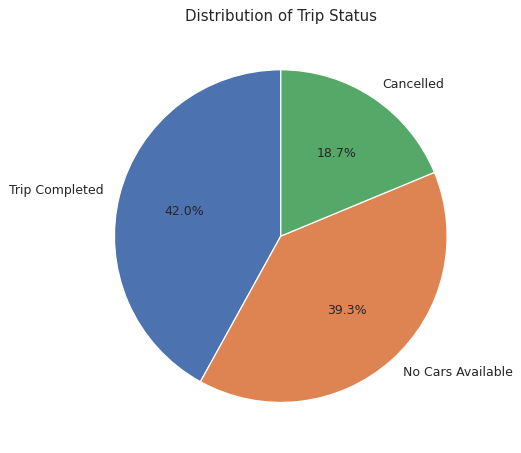

In [13]:
# Chart - 1 visualization code
plt.figure(figsize=(7, 6))
status_counts = df['Status'].value_counts()
colors = ['#4C72B0', '#DD8452', '#55A868']
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', startangle=90, colors=colors)
plt.title('Distribution of Trip Status')
plt.show()


##### 1. Why did you pick the specific chart?

A pie chart is ideal for showing how a whole (all 6,745 requests) breaks down into a few categories (the 3 status values) as proportions.

##### 2. What is/are the insight(s) found from the chart?

Only **42.0%** of requests end in a completed trip. The remaining **58.0%** are split almost evenly between **No Cars Available (39.3%)** and **Cancelled (18.7%)** — confirming a very large supply-demand gap.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — this quantifies the scale of the problem (58% lost trips), which justifies investment in fixing the gap. On its own it is a **negative-growth signal**: more than half of demand is currently going unserved, directly reducing Uber's revenue and rider trust.

#### Chart - 2

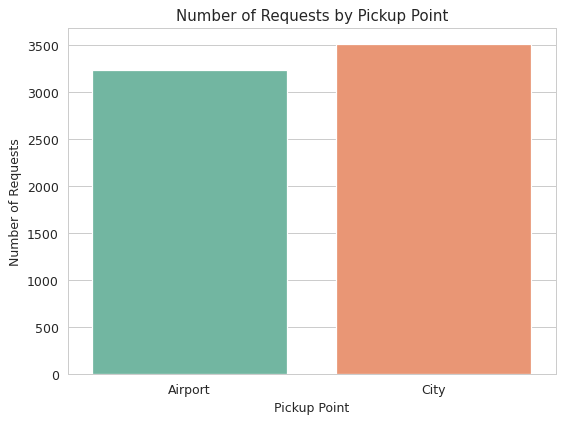

In [14]:
# Chart - 2 visualization code
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='Pickup point', hue='Pickup point', palette='Set2', legend=False)
plt.title('Number of Requests by Pickup Point')
plt.xlabel('Pickup Point')
plt.ylabel('Number of Requests')
plt.show()


##### 1. Why did you pick the specific chart?

A count/bar chart clearly compares total request volume between the two pickup points.

##### 2. What is/are the insight(s) found from the chart?

City generates slightly more requests (**3,507**) than the Airport (**3,238**), but the volumes are broadly comparable — the real difference between the two locations lies in *why* trips fail, not in raw demand.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — confirming that both pickup points have comparable demand means Uber should invest in solving the gap at **both** locations rather than treating one as a minor issue.

#### Chart - 3

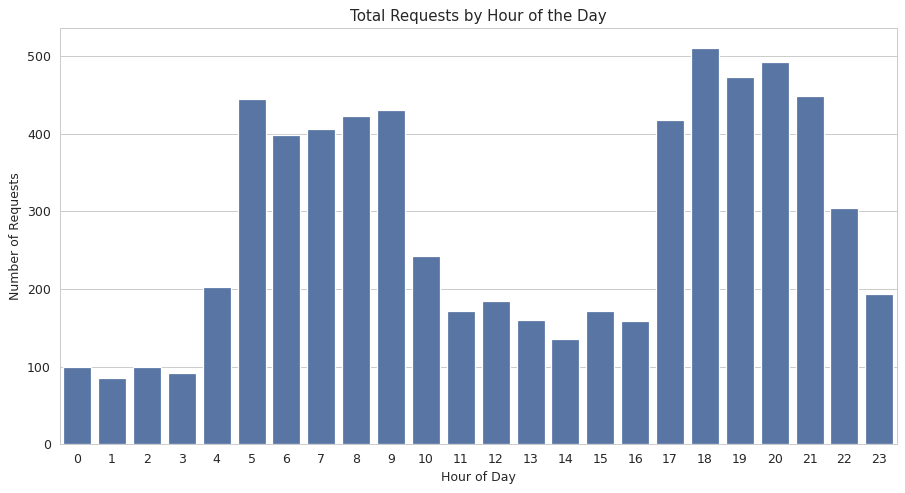

In [15]:
# Chart - 3 visualization code
plt.figure(figsize=(12, 6))
hourly_counts = df.groupby('Request Hour').size()
sns.barplot(x=hourly_counts.index, y=hourly_counts.values, color='#4C72B0')
plt.title('Total Requests by Hour of the Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Requests')
plt.show()


##### 1. Why did you pick the specific chart?

A bar chart across all 24 hours reveals the intraday demand pattern at a glance.

##### 2. What is/are the insight(s) found from the chart?

Requests show two clear demand peaks: one in the **early morning (5 AM - 9 AM)** and a larger one in the **evening (5 PM - 9 PM)** — typical commute-hour behavior — with a quiet trough between 11 AM and 4 PM.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — knowing exactly which hours drive demand lets Uber pre-position drivers ahead of the peaks, improving fulfillment without over-staffing the quiet afternoon hours.

#### Chart - 4

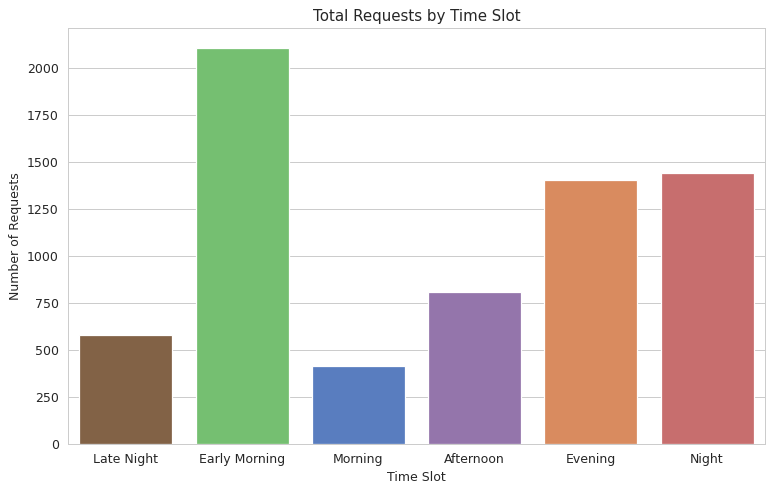

In [16]:
# Chart - 4 visualization code
plt.figure(figsize=(10, 6))
time_slot_order = ['Late Night', 'Early Morning', 'Morning', 'Afternoon', 'Evening', 'Night']
sns.countplot(data=df, x='Time Slot', order=time_slot_order, hue='Time Slot', palette='muted', legend=False)
plt.title('Total Requests by Time Slot')
plt.xlabel('Time Slot')
plt.ylabel('Number of Requests')
plt.show()


##### 1. Why did you pick the specific chart?

Grouping hours into time slots simplifies the 24-hour pattern into 6 interpretable operational windows, making comparisons easier than looking at 24 individual bars.

##### 2. What is/are the insight(s) found from the chart?

**Early Morning** has the highest request volume, followed by **Night** and **Evening**. **Morning** has the fewest requests of the day.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — this sets up the time-slot framework used for the rest of the analysis, letting Uber allocate driver incentives by slot rather than by individual hour.

#### Chart - 5

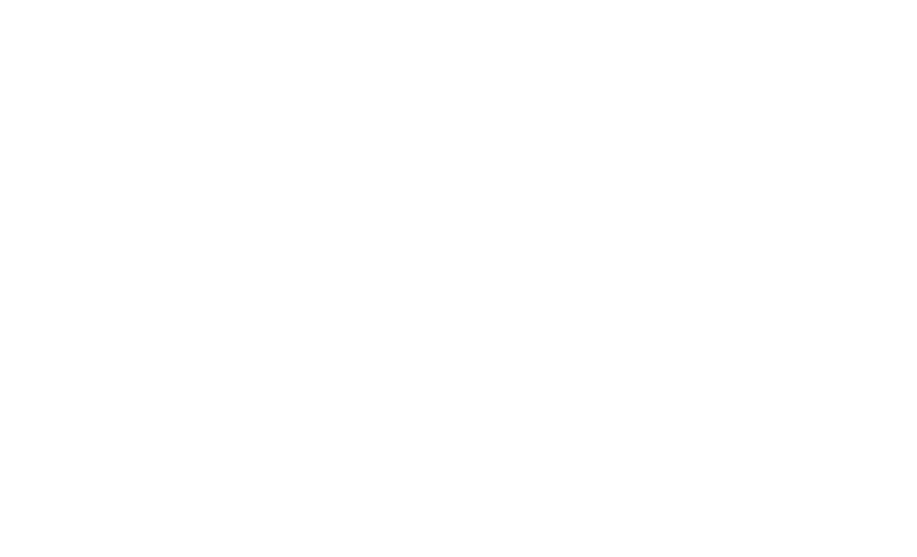

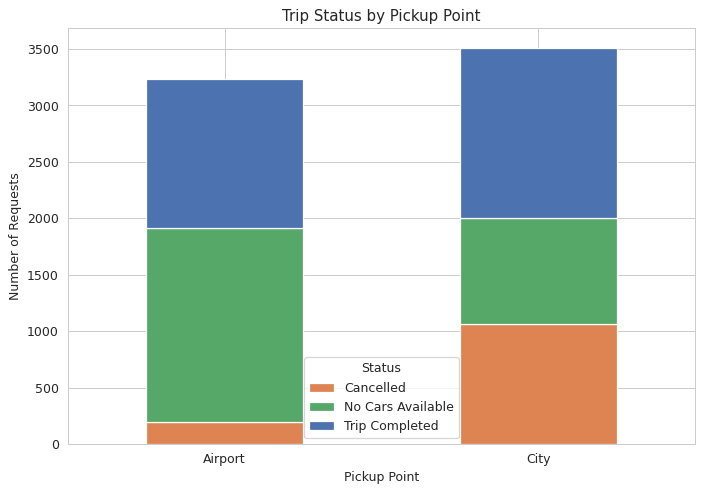

In [17]:
# Chart - 5 visualization code
plt.figure(figsize=(10, 6))
pd.crosstab(df['Pickup point'], df['Status']).plot(
    kind='bar', stacked=True, color=['#DD8452', '#55A868', '#4C72B0'], figsize=(9, 6)
)
plt.title('Trip Status by Pickup Point')
plt.xlabel('Pickup Point')
plt.ylabel('Number of Requests')
plt.xticks(rotation=0)
plt.legend(title='Status')
plt.show()


##### 1. Why did you pick the specific chart?

A stacked bar chart shows both the total volume per pickup point and how that volume splits across the 3 statuses in one view.

##### 2. What is/are the insight(s) found from the chart?

At the **Airport**, "No Cars Available" (1,713) dominates and cancellations are rare (198). In the **City**, it's the opposite: cancellations are very high (1,066) while "No Cars Available" is lower (937). The two locations fail for **completely different reasons**.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, this is one of the most actionable insights in the project — it shows Uber needs **two different fixes**: more driver supply at the Airport, and a way to stop drivers from cancelling City-to-Airport trips.

#### Chart - 6

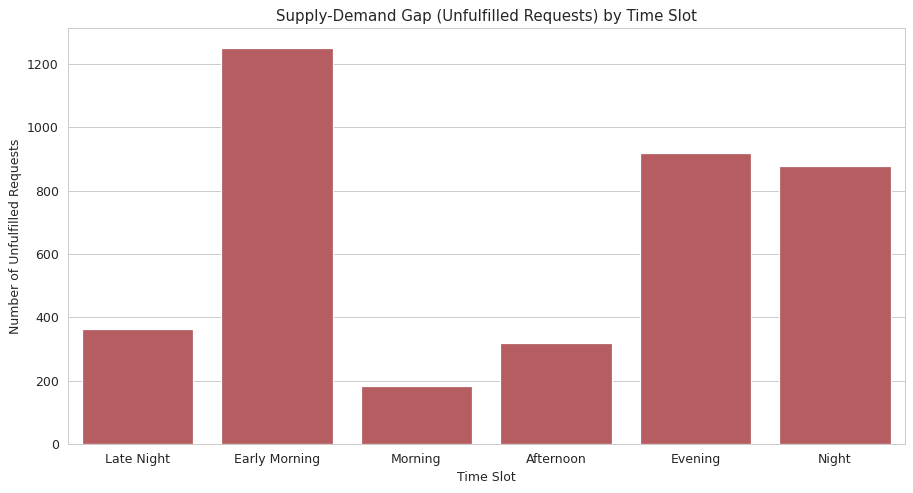

In [18]:
# Chart - 6 visualization code
plt.figure(figsize=(12, 6))
gap_by_slot = df[df['Is Gap'] == 1]['Time Slot'].value_counts().reindex(time_slot_order)
sns.barplot(x=gap_by_slot.index, y=gap_by_slot.values, color='#C44E52')
plt.title('Supply-Demand Gap (Unfulfilled Requests) by Time Slot')
plt.xlabel('Time Slot')
plt.ylabel('Number of Unfulfilled Requests')
plt.show()


##### 1. Why did you pick the specific chart?

This isolates only the *failed* requests (the gap) by time slot, which is the core metric this project is investigating.

##### 2. What is/are the insight(s) found from the chart?

The gap is largest during **Early Morning**, followed by **Evening** and **Night** — these three slots together account for the vast majority of all unfulfilled requests.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — this directly tells Uber *when* to focus supply-side interventions (incentives, shift bonuses) for maximum impact on reducing lost trips.

#### Chart - 7

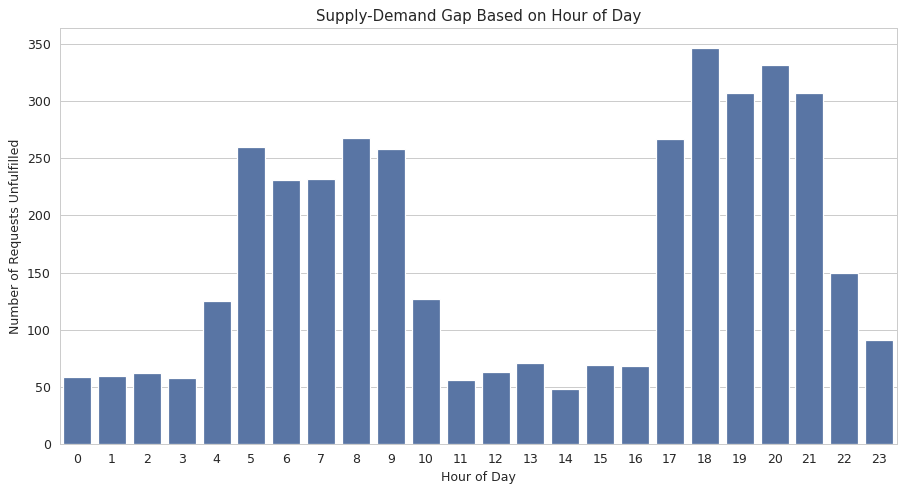

In [19]:
# Chart - 7 visualization code
plt.figure(figsize=(12, 6))
gap_by_hour = df[df['Is Gap'] == 1].groupby('Request Hour').size()
sns.barplot(x=gap_by_hour.index, y=gap_by_hour.values, color='#4C72B0')
plt.title('Supply-Demand Gap Based on Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Requests Unfulfilled')
plt.show()


##### 1. Why did you pick the specific chart?

Zooming into individual hours (instead of 6 broad slots) pinpoints exactly which hours inside a slot drive the gap.

##### 2. What is/are the insight(s) found from the chart?

The gap spikes sharply between **5 AM-9 AM** and again between **5 PM-9 PM**, mirroring the overall demand peaks seen in Chart 3 — meaning the busiest hours are also the least reliable hours for getting a cab.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — it shows the gap is a **peak-hour capacity problem**, not a random one, so solutions should specifically target driver availability during these narrow windows.

#### Chart - 8

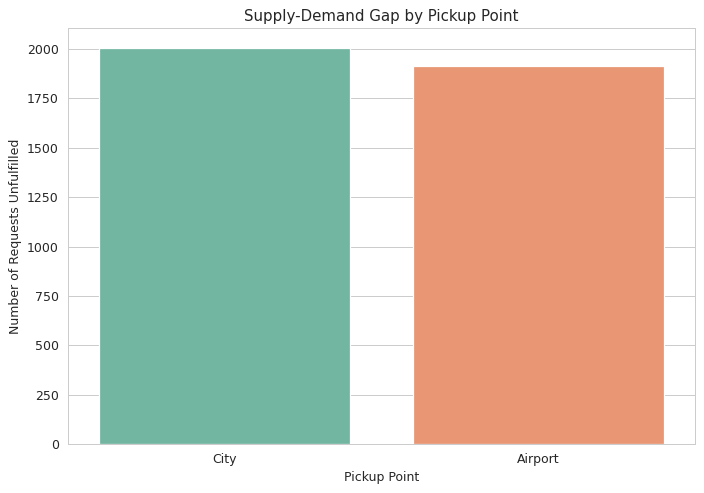

In [20]:
# Chart - 8 visualization code
plt.figure(figsize=(9, 6))
gap_by_point = df[df['Is Gap'] == 1]['Pickup point'].value_counts()
sns.barplot(x=gap_by_point.index, y=gap_by_point.values, hue=gap_by_point.index, palette='Set2', legend=False)
plt.title('Supply-Demand Gap by Pickup Point')
plt.xlabel('Pickup Point')
plt.ylabel('Number of Requests Unfulfilled')
plt.show()


##### 1. Why did you pick the specific chart?

A simple bar chart directly compares the total unfulfilled-request count between the two pickup points.

##### 2. What is/are the insight(s) found from the chart?

The **City** actually has a slightly larger absolute gap (2,003 unfulfilled) than the **Airport** (1,911), but as Chart 5 showed, the *composition* of that gap is completely different between the two locations.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — while raw gap counts are similar, this chart on its own could be misleading if read without Chart 5; together they show location-specific fixes are required rather than a one-size-fits-all solution.

#### Chart - 9

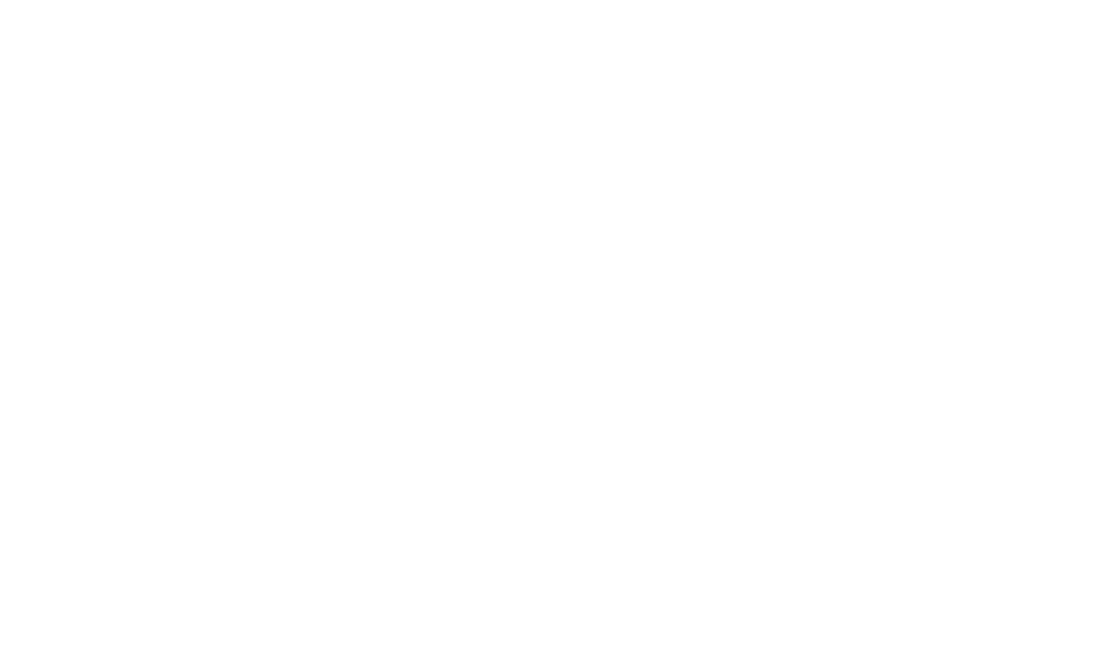

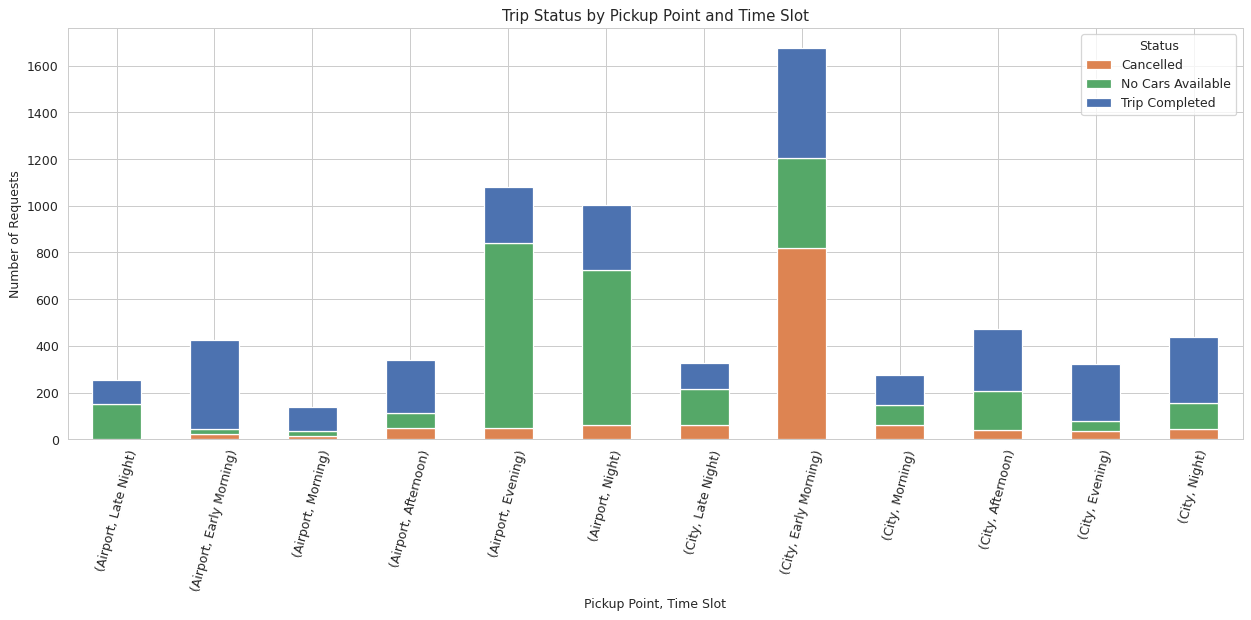

In [21]:
# Chart - 9 visualization code
plt.figure(figsize=(12, 7))
cross = pd.crosstab([df['Pickup point'], df['Time Slot']], df['Status'])
cross = cross.reindex(time_slot_order, level='Time Slot')
cross.plot(kind='bar', stacked=True, figsize=(14, 7), color=['#DD8452', '#55A868', '#4C72B0'])
plt.title('Trip Status by Pickup Point and Time Slot')
plt.xlabel('Pickup Point, Time Slot')
plt.ylabel('Number of Requests')
plt.xticks(rotation=75)
plt.legend(title='Status')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

This combines pickup point and time slot together (a 2-way breakdown) so we can see exactly where and when each type of failure happens simultaneously — similar to the treemap used in the original Tableau report.

##### 2. What is/are the insight(s) found from the chart?

**Airport + Evening** and **Airport + Night** are overwhelmingly "No Cars Available" (792 and 665 unfulfilled requests respectively), while **City + Early Morning** is overwhelmingly "Cancelled" (820 cancellations) — these specific combinations are by far the biggest single contributors to the entire supply-demand gap.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — this is the most granular, most actionable chart in the notebook: it names the exact problem segments (Airport-Evening/Night and City-Early Morning) that any fix should target first.

#### Chart - 10

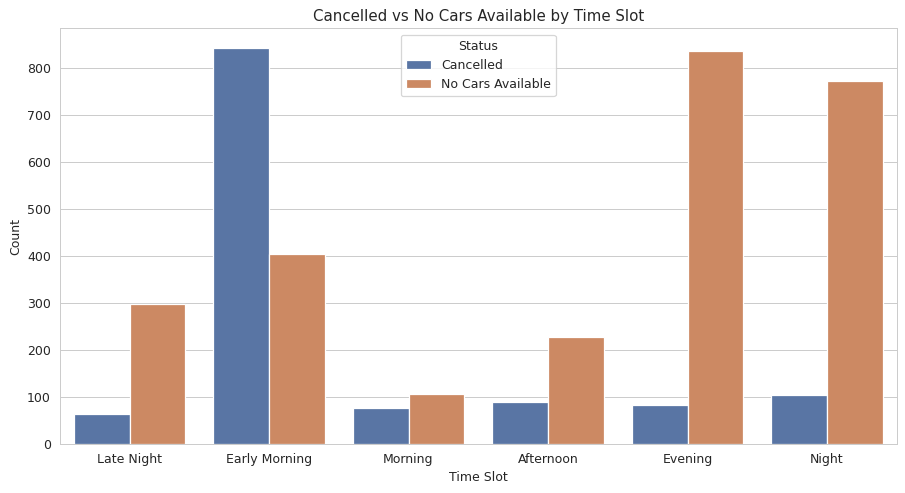

In [22]:
# Chart - 10 visualization code
plt.figure(figsize=(12, 6))
gap_only = df[df['Is Gap'] == 1]
sns.countplot(data=gap_only, x='Time Slot', hue='Status', order=time_slot_order,
              palette={'Cancelled': '#4C72B0', 'No Cars Available': '#DD8452'})
plt.title('Cancelled vs No Cars Available by Time Slot')
plt.xlabel('Time Slot')
plt.ylabel('Count')
plt.legend(title='Status')
plt.show()


##### 1. Why did you pick the specific chart?

A grouped count plot lets us compare the two failure types (Cancelled vs No Cars Available) side-by-side within every time slot.

##### 2. What is/are the insight(s) found from the chart?

**Cancellations peak in Early Morning and Morning**, while **"No Cars Available" peaks sharply at Night and Evening** — the two failure modes have almost opposite time patterns.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — since cancellations and unavailability need different remedies (driver behavior vs driver supply), knowing which one dominates each slot avoids wasting resources on the wrong fix.

#### Chart - 11

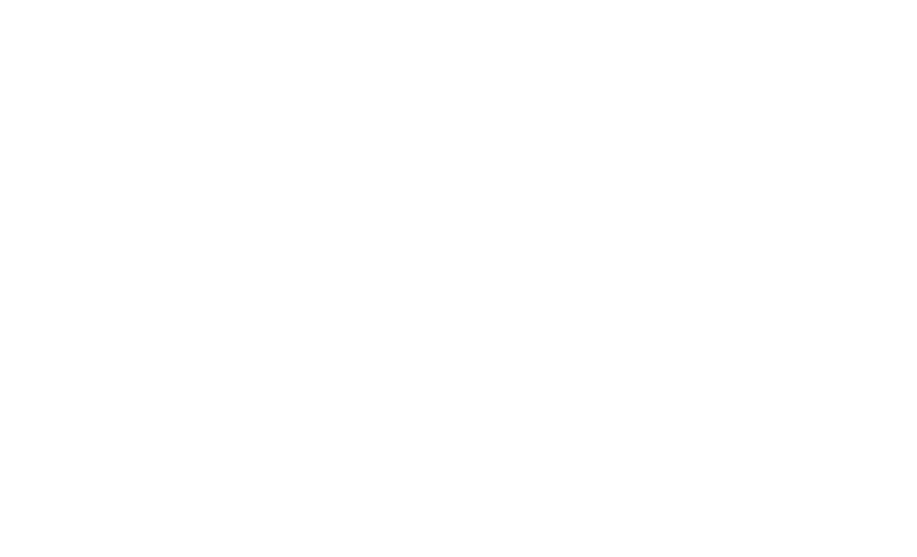

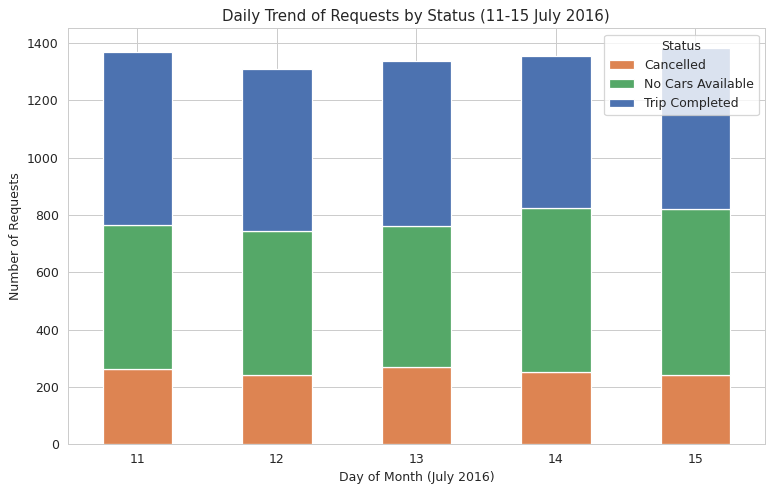

In [23]:
# Chart - 11 visualization code
plt.figure(figsize=(10, 6))
day_counts = df.groupby(['Request Day', 'Status']).size().unstack(fill_value=0)
day_counts.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#DD8452', '#55A868', '#4C72B0'])
plt.title('Daily Trend of Requests by Status (11-15 July 2016)')
plt.xlabel('Day of Month (July 2016)')
plt.ylabel('Number of Requests')
plt.xticks(rotation=0)
plt.legend(title='Status')
plt.show()


##### 1. Why did you pick the specific chart?

A stacked bar chart across the 5 days in the dataset checks whether the supply-demand gap is a one-off event or a **consistent daily pattern**.

##### 2. What is/are the insight(s) found from the chart?

The proportion of Cancelled / No Cars Available / Trip Completed is **remarkably consistent day-to-day** across all 5 days, confirming the gap is a **structural, recurring** operational issue rather than a one-time anomaly.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — because the pattern repeats daily, a fix implemented once (e.g., a standing night-shift incentive) will keep paying off every day rather than needing constant re-evaluation.

#### Chart - 12

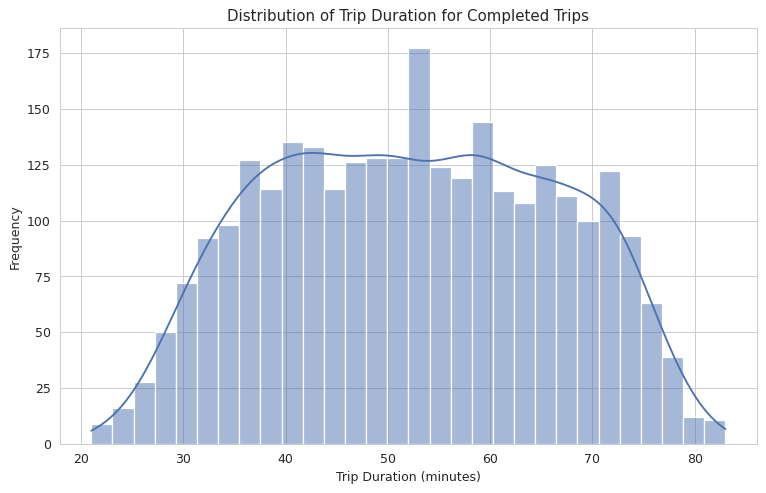

In [24]:
# Chart - 12 visualization code
plt.figure(figsize=(10, 6))
completed = df[df['Status'] == 'Trip Completed']
sns.histplot(completed['Trip Duration (mins)'], bins=30, kde=True, color='#4C72B0')
plt.title('Distribution of Trip Duration for Completed Trips')
plt.xlabel('Trip Duration (minutes)')
plt.ylabel('Frequency')
plt.show()


##### 1. Why did you pick the specific chart?

A histogram with a density curve is the standard way to see the shape (center, spread) of a continuous variable like trip duration.

##### 2. What is/are the insight(s) found from the chart?

Completed trips between City and Airport mostly last **around 50-60 minutes**, with a fairly narrow, roughly normal spread — consistent with a fixed City-Airport route length rather than highly variable in-city trips.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — knowing the typical ~1 hour round-trip-adjacent duration helps explain *why* drivers might avoid or cancel Airport trips (a driver is committed for roughly an hour and may return empty), directly supporting the cancellation-pattern insight from Chart 10.

#### Chart - 13

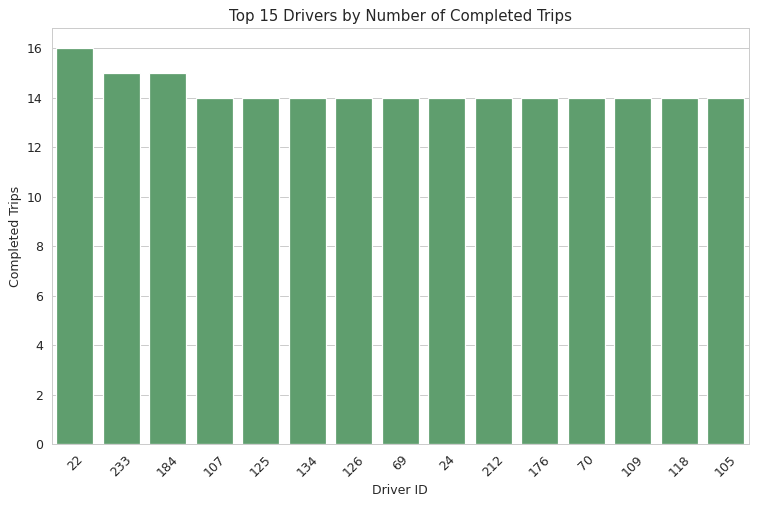

In [25]:
# Chart - 13 visualization code
plt.figure(figsize=(10, 6))
driver_trips = df[df['Status'] == 'Trip Completed'].groupby('Driver id').size()
top_drivers = driver_trips.sort_values(ascending=False).head(15)
sns.barplot(x=top_drivers.index.astype(int).astype(str), y=top_drivers.values, color='#55A868')
plt.title('Top 15 Drivers by Number of Completed Trips')
plt.xlabel('Driver ID')
plt.ylabel('Completed Trips')
plt.xticks(rotation=45)
plt.show()


##### 1. Why did you pick the specific chart?

A ranked bar chart highlights the highest performing drivers, useful for understanding whether trip completions are concentrated among a few drivers or spread evenly.

##### 2. What is/are the insight(s) found from the chart?

Completed trips are spread fairly evenly across drivers (median 9 trips per driver), with the busiest drivers completing only up to 16 trips over the 5-day period — there is no single dominant "super-driver" skewing the results.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes — an even spread means the gap is a **systemic supply/incentive issue affecting the whole driver pool**, not a performance issue with a few individual drivers, reinforcing that the fix should be policy-level (pricing/shifts) rather than driver-specific.

#### Chart - 14 - Correlation Heatmap

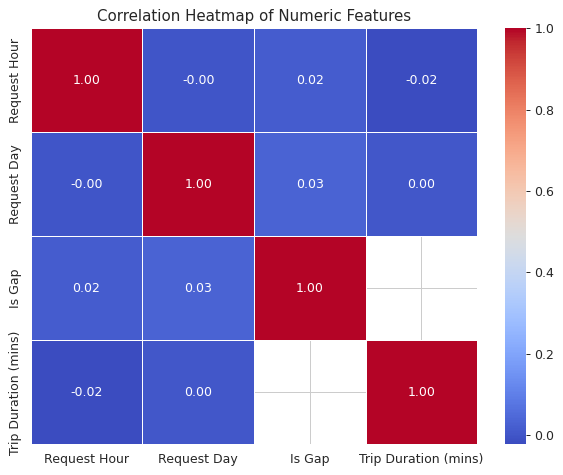

In [26]:
# Correlation Heatmap visualization code
plt.figure(figsize=(8, 6))
numeric_df = df[['Request Hour', 'Request Day', 'Is Gap', 'Trip Duration (mins)']].copy()
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()


##### 1. Why did you pick the specific chart?

A correlation heatmap quickly summarizes linear relationships between all numeric/engineered features in one compact view.

##### 2. What is/are the insight(s) found from the chart?

Correlations among `Request Hour`, `Request Day`, `Is Gap`, and `Trip Duration` are all **weak** (close to 0). This confirms the supply-demand gap is driven by the **categorical patterns** (time slot, pickup point) rather than by a simple linear relationship with hour or day alone.

#### Chart - 15 - Pair Plot

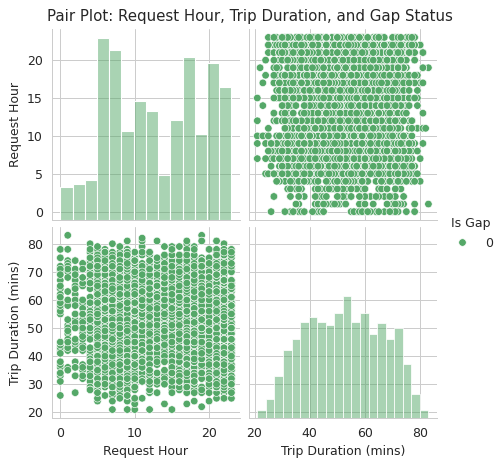

In [27]:
# Pair Plot visualization code
pairplot_df = df[['Request Hour', 'Trip Duration (mins)', 'Is Gap']].dropna()
sns.pairplot(pairplot_df, hue='Is Gap', palette={0: '#55A868', 1: '#C44E52'}, diag_kind='hist')
plt.suptitle('Pair Plot: Request Hour, Trip Duration, and Gap Status', y=1.02)
plt.show()


##### 1. Why did you pick the specific chart?

A pair plot shows pairwise relationships and individual distributions between the key numeric variables, split by whether the request was a gap, in a single grid.

##### 2. What is/are the insight(s) found from the chart?

Requests that are part of the gap (`Is Gap = 1`) are visibly concentrated at specific request hours (matching the morning/night peaks found earlier), while trip duration (only available for completed trips) clusters tightly around 50-60 minutes with little relationship to the hour of request.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

Based on the analysis, two targeted, data-backed levers are recommended:

1. **Rush-hour incentive pricing for City pickups (Early Morning):** Since cancellations are heavily concentrated when drivers accept a City-to-Airport request during the Early Morning slot, Uber should introduce a surge/incentive bonus specifically for completing City-to-Airport trips in this window. This directly counters the driver's incentive to cancel in favor of shorter, more frequent in-city trips.

2. **Dedicated evening/night-shift driver allocation at the Airport:** Since "No Cars Available" is heavily concentrated at the Airport during the Evening and Night slots, Uber should guarantee a minimum number of drivers stationed at or near the Airport during these hours (e.g., via shift bonuses or guaranteed minimum earnings), directly reducing the "No Cars Available" outcome for Airport pickups.

Both levers are targeted precisely at the two problem segments identified in Chart 9 (Airport+Evening/Night and City+Early Morning), meaning they should deliver the largest possible reduction in the supply-demand gap per rupee/dollar spent on incentives.

# **Conclusion**

This EDA of 6,745 Uber ride requests reveals that **58% of all requests are not completed** — split almost evenly between "No Cars Available" (39.3%) and "Cancelled" (18.7%). Crucially, these two failure modes are **not randomly distributed**: they are concentrated in specific, predictable time-slot and pickup-point combinations.

- **Airport pickups fail mostly due to "No Cars Available", concentrated in Evening and Night.**
- **City pickups fail mostly due to driver "Cancellations", concentrated in Early Morning.**
- The daily pattern is **consistent across all 5 days** in the dataset, confirming this is a structural operational issue rather than a one-off event.
- The gap is spread across the driver pool rather than caused by a handful of underperforming drivers, meaning the fix must be a **policy-level change** (pricing and shift incentives), not driver-specific retraining.

Implementing **rush-hour incentive pricing** for City-to-Airport trips in the morning and a **guaranteed night-shift driver pool** at the Airport directly target the two root causes identified and should meaningfully reduce unfulfilled requests, increasing completed trips, revenue, and customer trust in the Uber platform.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***